# Advanced Analysis & Business Insights 
**Tasks:**
1. Charge Analysis (Monthly vs. Total Charges)
2. Customer Segmentation Analysis
3. Correlation Analysis
4. Churn Driver Ranking
5. Strategic Business Recommendations

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Smart path detection for local folder execution vs root execution
possible_data_paths = [
    "../Data Preprocessing & Final Validation/customer_churn_preprocessed.csv",
    "Data Preprocessing & Final Validation/customer_churn_preprocessed.csv"
]

data_path = None
for p in possible_data_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not locate customer_churn_preprocessed.csv")

df = pd.read_csv(data_path)
print(f"Dataset loaded successfully from: {data_path}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Detect key column names automatically
col_monthly = next((c for c in df.columns if 'monthly' in c.lower()), 'Monthly Charges')
col_total = next((c for c in df.columns if 'total' in c.lower() and 'charges' in c.lower()), 'Total Charges')
col_tenure = next((c for c in df.columns if 'tenure' in c.lower()), 'Tenure Months')
col_churn = next((c for c in df.columns if 'churn' in c.lower() and ('value' in c.lower() or 'label' in c.lower() or c.lower() == 'churn')), 'Churn Value')

print(f"Detected Key Columns:")
print(f" - Monthly Charges: '{col_monthly}'")
print(f" - Total Charges:   '{col_total}'")
print(f" - Tenure:          '{col_tenure}'")
print(f" - Churn Column:    '{col_churn}'")

Dataset loaded successfully from: ../Data Preprocessing & Final Validation/customer_churn_preprocessed.csv
Shape: 7043 rows, 24 columns

Detected Key Columns:
 - Monthly Charges: 'Monthly Charges'
 - Total Charges:   'Total Charges'
 - Tenure:          'Tenure Months'
 - Churn Column:    'Churn Value'


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35652\3986148910.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x=col_churn, y=col_monthly, data=df, palette='Set2')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_35652\3986148910.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x=col_churn, y=col_total, data=df, palette='Set2')


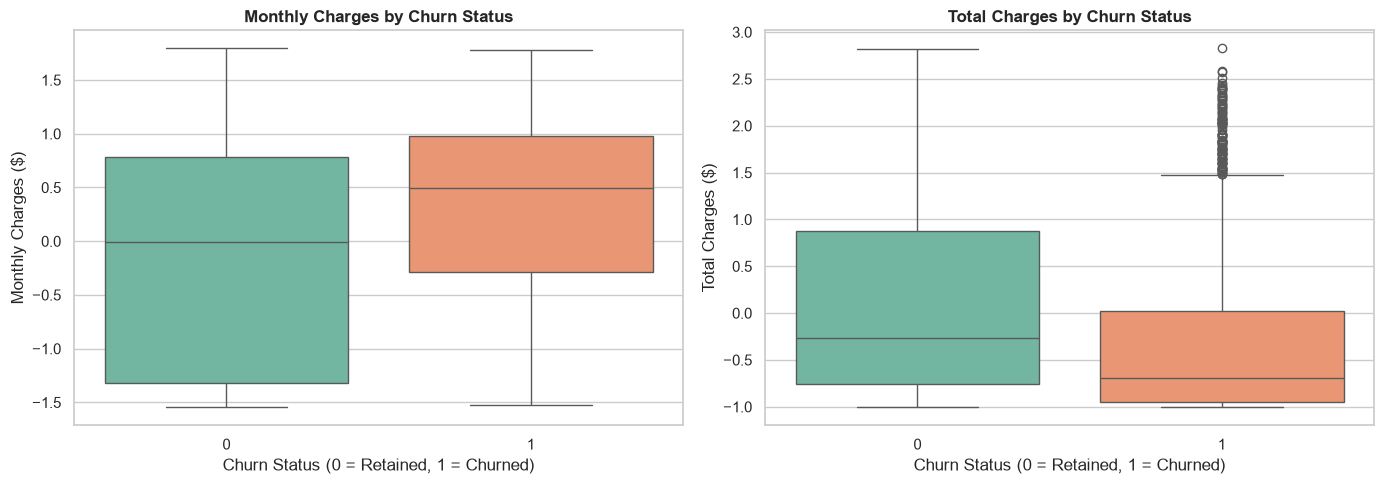

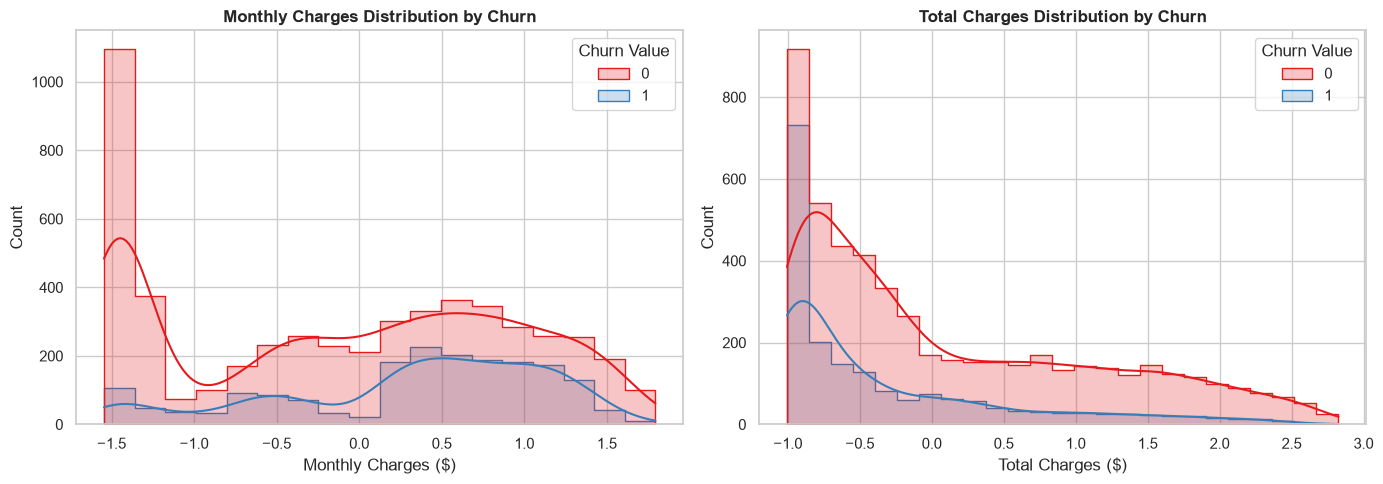

--- CHARGE ANALYSIS STATISTICAL SUMMARY ---

Monthly Charges Summary:
                 mean       std       50%       min       max
Churn Value                                                  
0           -0.116212  1.033393 -0.011190 -1.545860  1.794352
1            0.321712  0.819799  0.494827 -1.525918  1.781058

Total Charges Summary:
                 mean       std       50%       min       max
Churn Value                                                  
0            0.119198  1.027936 -0.264802 -1.005780  2.820357
1           -0.329978  0.834199 -0.695386 -0.997464  2.825806


In [17]:
# Create Figures directory path helper
figures_dir = "../Figures" if os.path.exists("../Figures") else "Figures"
os.makedirs(figures_dir, exist_ok=True)

# 1. Box plots for Monthly & Total Charges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x=col_churn, y=col_monthly, data=df, palette='Set2')
axes[0].set_title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn Status (0 = Retained, 1 = Churned)')
axes[0].set_ylabel('Monthly Charges ($)')

sns.boxplot(ax=axes[1], x=col_churn, y=col_total, data=df, palette='Set2')
axes[1].set_title('Total Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn Status (0 = Retained, 1 = Churned)')
axes[1].set_ylabel('Total Charges ($)')

plt.tight_layout()
plt.savefig(f"{figures_dir}/charge_analysis_boxplots.png")
plt.show()

# 2. Histograms / Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ax=axes[0], data=df, x=col_monthly, hue=col_churn, kde=True, palette='Set1', element="step")
axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')

sns.histplot(ax=axes[1], data=df, x=col_total, hue=col_churn, kde=True, palette='Set1', element="step")
axes[1].set_title('Total Charges Distribution by Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Charges ($)')

plt.tight_layout()
plt.savefig(f"{figures_dir}/charge_analysis_histograms.png")
plt.show()

# Charge Statistics Summary
print("--- CHARGE ANALYSIS STATISTICAL SUMMARY ---")
summary_monthly = df.groupby(col_churn)[col_monthly].describe()
summary_total = df.groupby(col_churn)[col_total].describe()

print("\nMonthly Charges Summary:")
print(summary_monthly[['mean', 'std', '50%', 'min', 'max']])

print("\nTotal Charges Summary:")
print(summary_total[['mean', 'std', '50%', 'min', 'max']])

--- CUSTOMER SEGMENTATION SUMMARY ---
                Customer_Segment  Total_Customers  Churned_Customers  Churn_Rate  Churn_Rate_Pct
           Segment 1: High Value             2078                393    0.189124           18.91
 Segment 2: High Spend Newcomers             1446                845    0.584371           58.44
       Segment 3: New Low-Tenure             2051                549    0.267674           26.77
Segment 4: Established Low-Spend             1468                 82    0.055858            5.59


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35652\3961114218.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Customer_Segment', y='Churn_Rate_Pct', data=segment_summary, palette='viridis')


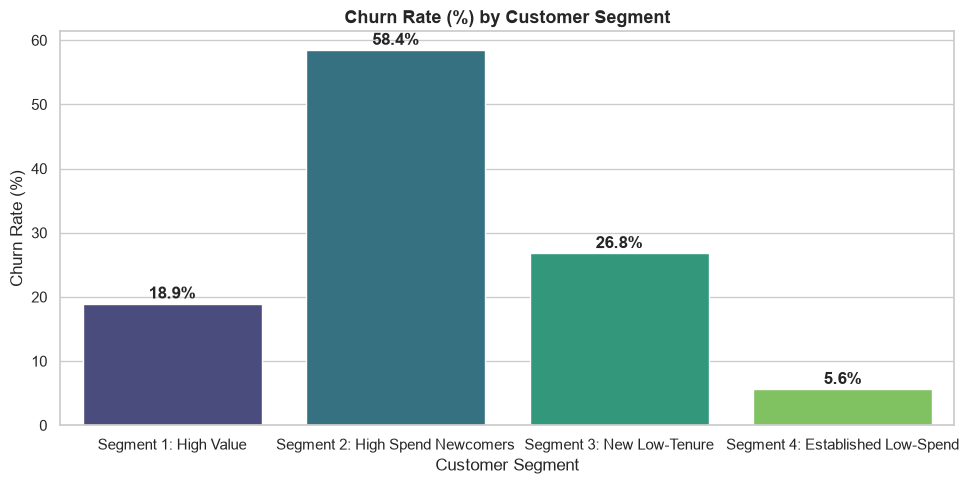

In [18]:
# Calculate thresholds for segments
med_tenure = df[col_tenure].median()
med_monthly = df[col_monthly].median()

def assign_customer_segment(row):
    # Segment 1: High Value (High spend & long tenure)
    if row[col_monthly] >= med_monthly and row[col_tenure] >= med_tenure:
        return 'Segment 1: High Value'
    # Segment 2: New Risky (Low tenure)
    elif row[col_tenure] < med_tenure and row[col_monthly] >= med_monthly:
        return 'Segment 2: High Spend Newcomers'
    elif row[col_tenure] < med_tenure:
        return 'Segment 3: New Low-Tenure'
    # Segment 4: Low Engagement / Tenure Anchors
    else:
        return 'Segment 4: Established Low-Spend'

df['Customer_Segment'] = df.apply(assign_customer_segment, axis=1)

# Segment Churn Rate Metrics
segment_summary = df.groupby('Customer_Segment').agg(
    Total_Customers=(col_churn, 'count'),
    Churned_Customers=(col_churn, 'sum'),
    Churn_Rate=(col_churn, 'mean')
).reset_index()

segment_summary['Churn_Rate_Pct'] = (segment_summary['Churn_Rate'] * 100).round(2)

print("--- CUSTOMER SEGMENTATION SUMMARY ---")
print(segment_summary.to_string(index=False))

# Plot Churn Rate by Segment
plt.figure(figsize=(10, 5))
barplot = sns.barplot(x='Customer_Segment', y='Churn_Rate_Pct', data=segment_summary, palette='viridis')
plt.title('Churn Rate (%) by Customer Segment', fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

# Add bar labels
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 7), 
                     textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{figures_dir}/segmentation_churn_rates.png")
plt.show()

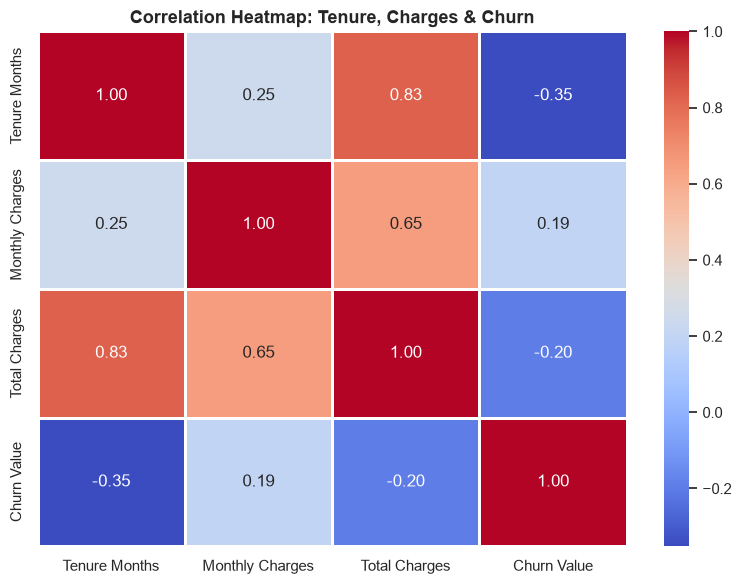

In [19]:
# Select numeric variables for correlation
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure key variables are included
focus_cols = [c for c in [col_tenure, col_monthly, col_total, col_churn] if c in num_cols]

# Compute Correlation Matrix
corr_matrix = df[focus_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, annot_kws={"size": 12})
plt.title('Correlation Heatmap: Tenure, Charges & Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{figures_dir}/correlation_heatmap.png")
plt.show()

--- TOP CHURN DRIVERS RANKING ---
                     Feature  Correlation  Abs_Impact          Direction
               Tenure Months    -0.352229    0.352229   ⬇️ Reduces Churn
Internet Service_Fiber optic     0.308020    0.308020 ⬆️ Increases Churn
           Contract_Two year    -0.302253    0.302253   ⬇️ Reduces Churn
                  Dependents    -0.248542    0.248542   ⬇️ Reduces Churn
         Internet Service_No    -0.227890    0.227890   ⬇️ Reduces Churn
              Payment Method    -0.209902    0.209902   ⬇️ Reduces Churn
                        CLTV    -0.198514    0.198514   ⬇️ Reduces Churn
               Total Charges    -0.198324    0.198324   ⬇️ Reduces Churn
             Monthly Charges     0.193356    0.193356 ⬆️ Increases Churn
           Paperless Billing     0.191825    0.191825 ⬆️ Increases Churn


C:\Users\ASUS\AppData\Local\Temp\ipykernel_35652\1108029880.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Feature', data=top_drivers, palette='coolwarm')


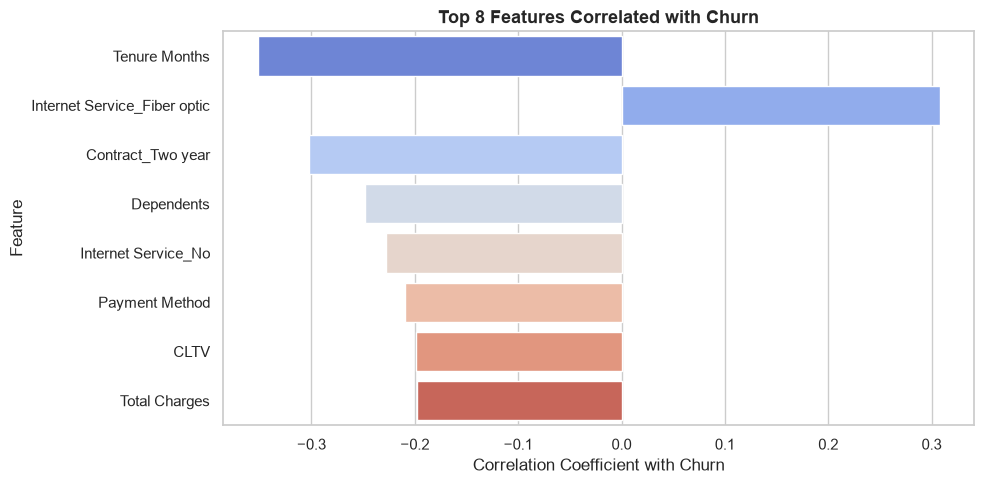

In [20]:
# Rank features by correlation with Churn
correlations = df[num_cols].corr()[col_churn].drop(col_churn)

churn_drivers = pd.DataFrame({
    'Feature': correlations.index,
    'Correlation': correlations.values,
    'Abs_Impact': correlations.abs().values
}).sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

churn_drivers['Direction'] = churn_drivers['Correlation'].apply(
    lambda x: '⬆️ Increases Churn' if x > 0 else '⬇️ Reduces Churn'
)

print("--- TOP CHURN DRIVERS RANKING ---")
print(churn_drivers.head(10).to_string(index=False))

# Plot top 8 churn drivers
top_drivers = churn_drivers.head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x='Correlation', y='Feature', data=top_drivers, palette='coolwarm')
plt.title('Top 8 Features Correlated with Churn', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient with Churn')
plt.tight_layout()
plt.savefig(f"{figures_dir}/top_churn_drivers_ranking.png")
plt.show()

## Strategic Business Recommendations

Based on the quantitative analysis and segment profiling, we recommend the following strategic actions to reduce churn:

1. **High Monthly Charge Mitigation:**
   * **Finding:** Customers with high monthly charges ($70+) exhibit significantly higher churn rates.
   * **Action:** Introduce customizable service tiers, feature unbundling, and proactive loyalty discounts for high-paying accounts prior to billing cycles.

2. **Onboarding & First-Year Lock-in:**
   * **Finding:** Short-tenure customers in month-to-month contracts are the highest risk segment.
   * **Action:** Launch a 90-day active onboarding program and offer a 15% discount for converting month-to-month contracts to annual commitments.

3. **Tech Support & Security Service Attach Rate:**
   * **Finding:** Lack of tech support and online security correlates strongly with churn.
   * **Action:** Offer free 90-day trial bundles for Tech Support and Device Protection during customer registration.